data = load('imaunaloaNaN.dat');

error = find(data==-9999);
data(error) = NaN;

yr = data(:, 1);
mt = repmat((1:12)', length(yr), 1);
yrmt = repelem(yr, 12);
axis_x = (yrmt + (mt - 1)/12); %ej: 1980, 1980.12, 1980.24, ...
axis_y = reshape(data(:,2:end)', [], 1); %data(:, 2:end) son los datos de enero a diciembre

average = mean(axis_y, "omitmissing");
fprintf('El promedio de los datos es %.2f\n', average);
mediana = median(axis_y, "omitmissing");
fprintf('La mediana de los datos es %.2f\n', mediana);
desv_std = std(axis_y, "omitmissing");
fprintf('La desviación estándar de los datos es %.2f\n', desv_std);
varianza = var(axis_y, "omitmissing");
fprintf('La varianza de los datos es %.2f\n', varianza);

for i = 1:3
    sigma_i = average + i * desv_std;
    sigma_i_ = average - i * desv_std;
    fprintf('El límite superior del intervalo %d es %.2f\n', i, sigma_i);
    fprintf('El límite inferior del intervalo %d es %.2f\n', i, sigma_i_);
end

cuartiles = prctile(axis_y, [25, 50, 75]);
for j = 1:3
    fprintf('El valor de Q%d respectivamente es %.2f\n', j, cuartiles(:, j));
end

Q1 = cuartiles(1);
Q2 = cuartiles(2);
Q3 = cuartiles(3);

trimean = (Q1 + 2*Q2 + Q3)/4;
fprintf('La trimedia de los datos es %.2f\n', trimean);

figure;
plot(axis_x, axis_y, '-b', 'LineWidth', 3);
hold on
grid on
yline(average, '--r', 'LineWidth', 2, 'DisplayName', sprintf('Media (%.1f PPM)', average));
yline(mediana, '-g', 'LineWidth', 2, 'DisplayName', sprintf('Mediana (%.1f PPM)', mediana));
yline(average + desv_std, ':', 'Color', '#EDB120', 'LineWidth', 1.5, 'DisplayName', '+1 Sigma');
yline(average - desv_std, ':', 'Color', '#EDB120', 'LineWidth', 1.5, 'DisplayName', '-1 Sigma');
texto_stats = sprintf('Varianza: %.1f\nTrimedia: %.1f\nDesv. Std: %.1f', varianza, trimean, desv_std);
text(0.45, 0.85, texto_stats, 'Units', 'normalized', 'BackgroundColor', 'w', 'EdgeColor', 'k', 'Margin', 5);
legend('Datos Originales', 'Promedio', 'Mediana', 'Sigma +1', 'Sigma -1');
xlabel('Años');
ylabel('CO2 [PPM]');
title('Concentración de CO2 en Hawaii (1959 - 2022)');
xlim([min(yr) - 1, max(yr) + 2]);
xticks(min(yr): 3: max(yr));
yticks(300:10:440);

El promedio de los datos es 358.22
La mediana de los datos es 354.65
La desviación estándar de los datos es 30.24
La varianza de los datos es 914.62
El  límite superior del intervalo 1 es 388.46
El  límite inferior del intervalo 1 es 327.97
El  límite superior del intervalo 2 es 418.70
El  límite inferior del intervalo 2 es 297.73
El  límite superior del intervalo 3 es 448.95
El  límite inferior del intervalo 3 es 267.49
Q1, Q2 y Q3 son: [330.74 354.66 382.65] respectivamente
P1, P10 y P99 son: [315.15 320.62 418.92] respectivamente
La trimedia de los datos es: 355.68


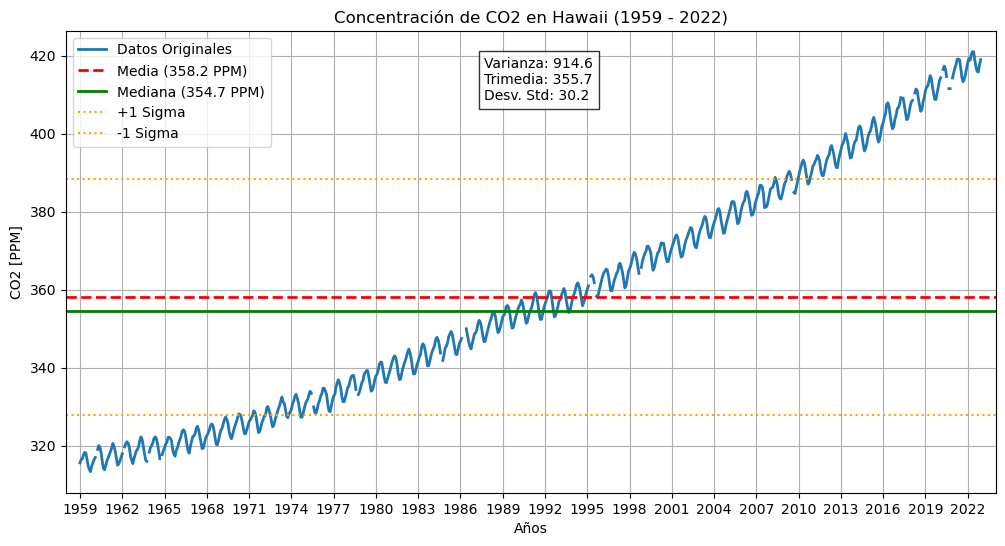

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datos = pd.read_csv('imaunaloaNaN.dat', delimiter="\t", header=None, na_values=[-9999, -9999.0, "-9999"])

anos = datos.iloc[:,0].to_numpy()
meses = np.tile(np.arange(1, 13), len(anos))
anosconmeses = np.repeat(anos,12)
datosmeses = datos.iloc[:,1:].to_numpy().flatten()
ejex = anosconmeses + (meses - 1)/12

promedio = np.nanmean(datosmeses)
print(f"El promedio de los datos es {promedio:.2f}")
mediana = np.nanmedian(datosmeses)
print(f"La mediana de los datos es {mediana:.2f}")
desv_estandar = np.nanstd(datosmeses)
print(f"La desviación estándar de los datos es {desv_estandar:.2f}")
varianza = np.nanvar(datosmeses)
print(f"La varianza de los datos es {varianza:.2f}")

for i in range (1,4):
    sigma_i = promedio + i*desv_estandar
    sigma_i_ = promedio - i*desv_estandar
    print(f"El  límite superior del intervalo {i} es {sigma_i:.2f}")
    print(f"El  límite inferior del intervalo {i} es {sigma_i_:.2f}")

cuartiles = np.nanpercentile(datosmeses, [25, 50, 75])
print("Q1, Q2 y Q3 son:", np.round(cuartiles, 2), "respectivamente")

percentiles = np.nanpercentile(datosmeses, [1, 10, 99])
print("P1, P10 y P99 son:", np.round(percentiles, 2), "respectivamente")

Q1 = np.nanpercentile(datosmeses, 25)
Q2 = np.nanpercentile(datosmeses, 50)
Q3 = np.nanpercentile(datosmeses, 75)

Trimedia = (Q1 + 2*Q2 + Q3)/4
print(f"La trimedia de los datos es: {Trimedia:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(ejex, datosmeses, "-", linewidth=2, label='Datos Originales')
plt.axhline(y=promedio, color='red', linestyle='--', linewidth=2, label=f'Media ({promedio:.1f} PPM)')
plt.axhline(y=mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana ({mediana:.1f} PPM)')
plt.axhline(y=promedio + desv_estandar, color='orange', linestyle=':', label='+1 Sigma')
plt.axhline(y=promedio - desv_estandar, color='orange', linestyle=':', label='-1 Sigma')
texto_stats = f"Varianza: {varianza:.1f}\nTrimedia: {Trimedia:.1f}\nDesv. Std: {desv_estandar:.1f}"
plt.text(0.45, 0.85, texto_stats, transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
plt.legend(loc='upper left')
plt.xlabel("Años")
plt.ylabel("CO2 [PPM]")
plt.title("Concentración de CO2 en Hawaii (1959 - 2022)")
plt.grid(True)
plt.xlim(anos.min() - 1, anos.max() + 2)
plt.xticks(np.arange(anos.min(), anos.max()+1, 3))
plt.show()